# 02 MSW survival probability
Two-flavor adiabatic toy calculation.

In [1]:
from pathlib import Path
import os, sys
PROJECT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT / "outputs" / "mplconfig"))
(PROJECT / "outputs").mkdir(exist_ok=True)
(PROJECT / "outputs" / "mplconfig").mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from solar_neutrino.constants import theta12_reference, dm21_reference
from solar_neutrino.oscillations import OscillationParameters, compute_survival_probability_grid, resonance_density
from solar_neutrino.plotting import plot_pee

## Toy electron density profile

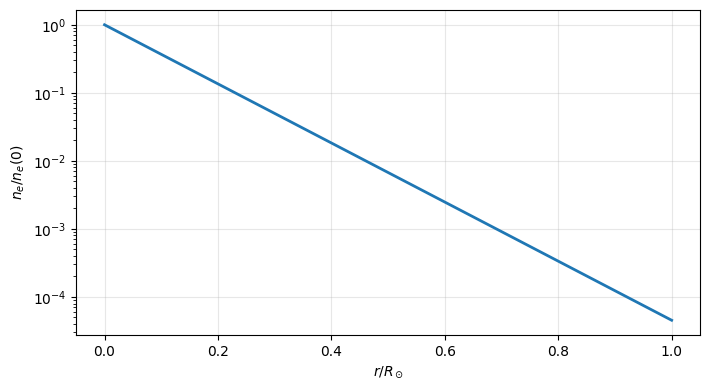

In [2]:
density = pd.read_csv(PROJECT / "data" / "electron_density_profile_toy.csv")
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.semilogy(density["r_over_Rsun"], density["ne_normalized"], lw=2)
ax.set_xlabel(r"$r/R_\odot$"); ax.set_ylabel(r"$n_e/n_e(0)$"); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(PROJECT / "outputs" / "electron_density_profile_notebook.png", dpi=160); plt.show()

## Survival probability

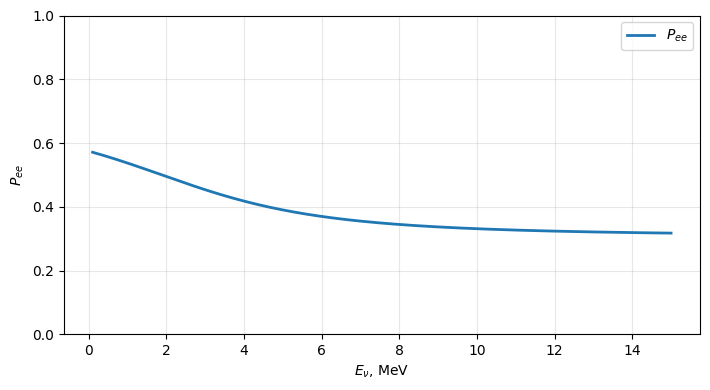

In [3]:
E_grid = np.linspace(0.1, 15.0, 240)
Pee = compute_survival_probability_grid(E_grid, OscillationParameters())
fig, ax = plt.subplots(figsize=(7.2, 4.0))
plot_pee(E_grid, Pee, ax=ax)
fig.tight_layout(); fig.savefig(PROJECT / "outputs" / "pee_grid_notebook.png", dpi=160); plt.show()

## Parameter variation

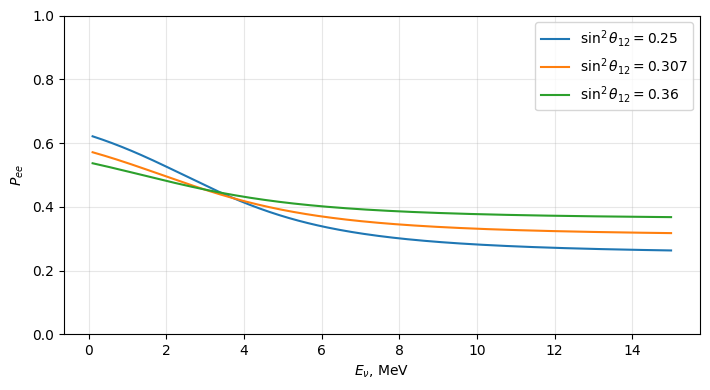

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for sin2 in [0.25, 0.307, 0.36]:
    theta = np.arcsin(np.sqrt(sin2))
    ax.plot(E_grid, compute_survival_probability_grid(E_grid, OscillationParameters(theta=theta)), label=fr"$\sin^2\theta_{{12}}={sin2}$")
ax.set_xlabel(r"$E_\nu$, MeV"); ax.set_ylabel(r"$P_{ee}$"); ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(PROJECT / "outputs" / "pee_parameter_variation.png", dpi=160); plt.show()

## Resonance density

In [5]:
E_check = np.array([1.0, 5.0, 10.0])
pd.DataFrame({"E_MeV": E_check, "ne_res_cm3": resonance_density(E_check, dm21_reference, theta12_reference)})

,E_MeV,ne_res_cm3
0,1.0,1.129919e+26
1,5.0,2.259837e+25
2,10.0,1.129919e+25
